# 📊 File 01 — Phân tích khám phá dữ liệu (EDA)
**Brain Tumor Classification MRI Dataset**

Mục tiêu của file này:
- Hiểu cấu trúc và phân phối dữ liệu
- Kiểm tra chất lượng ảnh
- Phát hiện mất cân bằng dữ liệu (class imbalance)
- Khám phá đặc điểm pixel của từng loại u não

## 📦 Phần A — Import thư viện

In [1]:
# ============================================================
# Import tất cả thư viện cần thiết
# ============================================================
import os                          # Thao tác với file, thư mục
import numpy as np                 # Tính toán số học
import pandas as pd                # Xử lý bảng dữ liệu
import matplotlib.pyplot as plt    # Vẽ biểu đồ cơ bản
import seaborn as sns              # Vẽ biểu đồ đẹp hơn
import cv2                         # Đọc và xử lý ảnh
from PIL import Image              # Đọc ảnh bằng Pillow
from pathlib import Path           # Xử lý đường dẫn file
import warnings
warnings.filterwarnings('ignore')  # Tắt cảnh báo không cần thiết

# Cài đặt style cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 📁 Phần B — Cấu hình đường dẫn dữ liệu

⚠️ **Quan trọng:** Sửa `DATA_DIR` thành đường dẫn thực tế trên máy bạn!

In [3]:
# ============================================================
# Cấu hình đường dẫn — SỬA LẠI CHO ĐÚNG MÁY BẠN
# ============================================================

# Ví dụ Windows: r'C:\Users\TenBan\brain-tumor-project\data'
# Ví dụ Mac/Linux: '/home/username/brain-tumor-project/data'
BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR /'data'      

TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR  = DATA_DIR / 'Testing'

# Tên 4 class (loại u)
CLASSES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Tên hiển thị cho đẹp
CLASS_LABELS = {
    'glioma_tumor':     'Glioma',
    'meningioma_tumor': 'Meningioma',
    'no_tumor':         'Không có u',
    'pituitary_tumor':  'Pituitary'
}

# Kiểm tra đường dẫn có tồn tại không
assert TRAIN_DIR.exists(), f'❌ Không tìm thấy: {TRAIN_DIR}'
assert TEST_DIR.exists(),  f'❌ Không tìm thấy: {TEST_DIR}'

print(f'✅ Đường dẫn hợp lệ!')
print(f'   Train: {TRAIN_DIR}')
print(f'   Test:  {TEST_DIR}')

✅ Đường dẫn hợp lệ!
   Train: c:\Brainrost\Diabetic-Retinopathy-Detection-via-AI\data\Training
   Test:  c:\Brainrost\Diabetic-Retinopathy-Detection-via-AI\data\Testing


## 📊 Phần C — Đếm số lượng ảnh mỗi class

Bước quan trọng nhất trong EDA — kiểm tra xem dữ liệu có **cân bằng** không.
Nếu một class có quá ít ảnh so với class khác → model sẽ bị thiên lệch!

In [ ]:
# ============================================================
# Đếm số ảnh trong Train và Test theo từng class
# ============================================================
def count_images(base_dir, classes):
    """
    Đếm số ảnh trong mỗi thư mục class.
    Trả về dictionary: {class_name: số_lượng_ảnh}
    """
    counts = {}
    for cls in classes:
        cls_path = base_dir / cls
        # Chỉ đếm file ảnh (jpg, jpeg, png)
        images = list(cls_path.glob('*.jpg')) + \
                 list(cls_path.glob('*.jpeg')) + \
                 list(cls_path.glob('*.png'))
        counts[cls] = len(images)
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts  = count_images(TEST_DIR,  CLASSES)

# Tạo DataFrame để xem đẹp hơn
df_counts = pd.DataFrame({
    'Class':    [CLASS_LABELS[c] for c in CLASSES],
    'Training': [train_counts[c] for c in CLASSES],
    'Testing':  [test_counts[c]  for c in CLASSES],
})
df_counts['Tổng'] = df_counts['Training'] + df_counts['Testing']
df_counts['% Training'] = (df_counts['Training'] / df_counts['Training'].sum() * 100).round(1)

print('📊 Phân phối dữ liệu:')
print(df_counts.to_string(index=False))
print(f'\nTổng Training: {df_counts["Training"].sum()} ảnh')
print(f'Tổng Testing:  {df_counts["Testing"].sum()} ảnh')
print(f'Tổng cộng:     {df_counts["Tổng"].sum()} ảnh')

📊 Phân phối dữ liệu:
     Class  Training  Testing  Tổng  % Training
    Glioma       826      100   926        28.8
Meningioma       822      115   937        28.6
Không có u       395      105   500        13.8
 Pituitary       827       74   901        28.8

Tổng Training: 2870 ảnh
Tổng Testing:  394 ảnh
Tổng cộng:     3264 ảnh


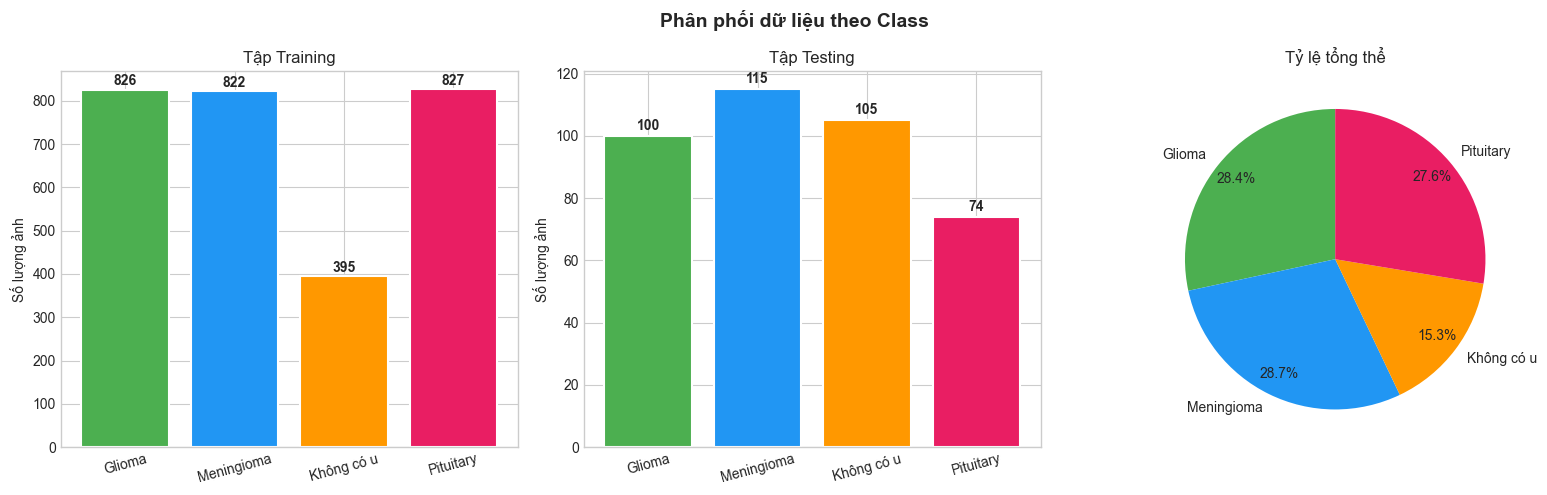

💾 Đã lưu: eda_class_distribution.png


In [ ]:
# ============================================================
# Vẽ biểu đồ phân phối dữ liệu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phân phối dữ liệu theo Class', fontsize=14, fontweight='bold')

colors = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']
labels = [CLASS_LABELS[c] for c in CLASSES]

# --- Biểu đồ 1: Bar chart Training ---
axes[0].bar(labels, [train_counts[c] for c in CLASSES], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tập Training')
axes[0].set_ylabel('Số lượng ảnh')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate([train_counts[c] for c in CLASSES]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# --- Biểu đồ 2: Bar chart Testing ---
axes[1].bar(labels, [test_counts[c] for c in CLASSES], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Tập Testing')
axes[1].set_ylabel('Số lượng ảnh')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate([test_counts[c] for c in CLASSES]):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

# --- Biểu đồ 3: Pie chart tổng ---
totals = [train_counts[c] + test_counts[c] for c in CLASSES]
axes[2].pie(totals, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[2].set_title('Tỷ lệ tổng thể')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: eda_class_distribution.png')

## 🖼️ Phần D — Hiển thị mẫu ảnh từng class

Nhìn trực tiếp vào ảnh để hiểu dữ liệu trông như thế nào,
và kiểm tra xem ảnh có bị lỗi hay có gì bất thường không.

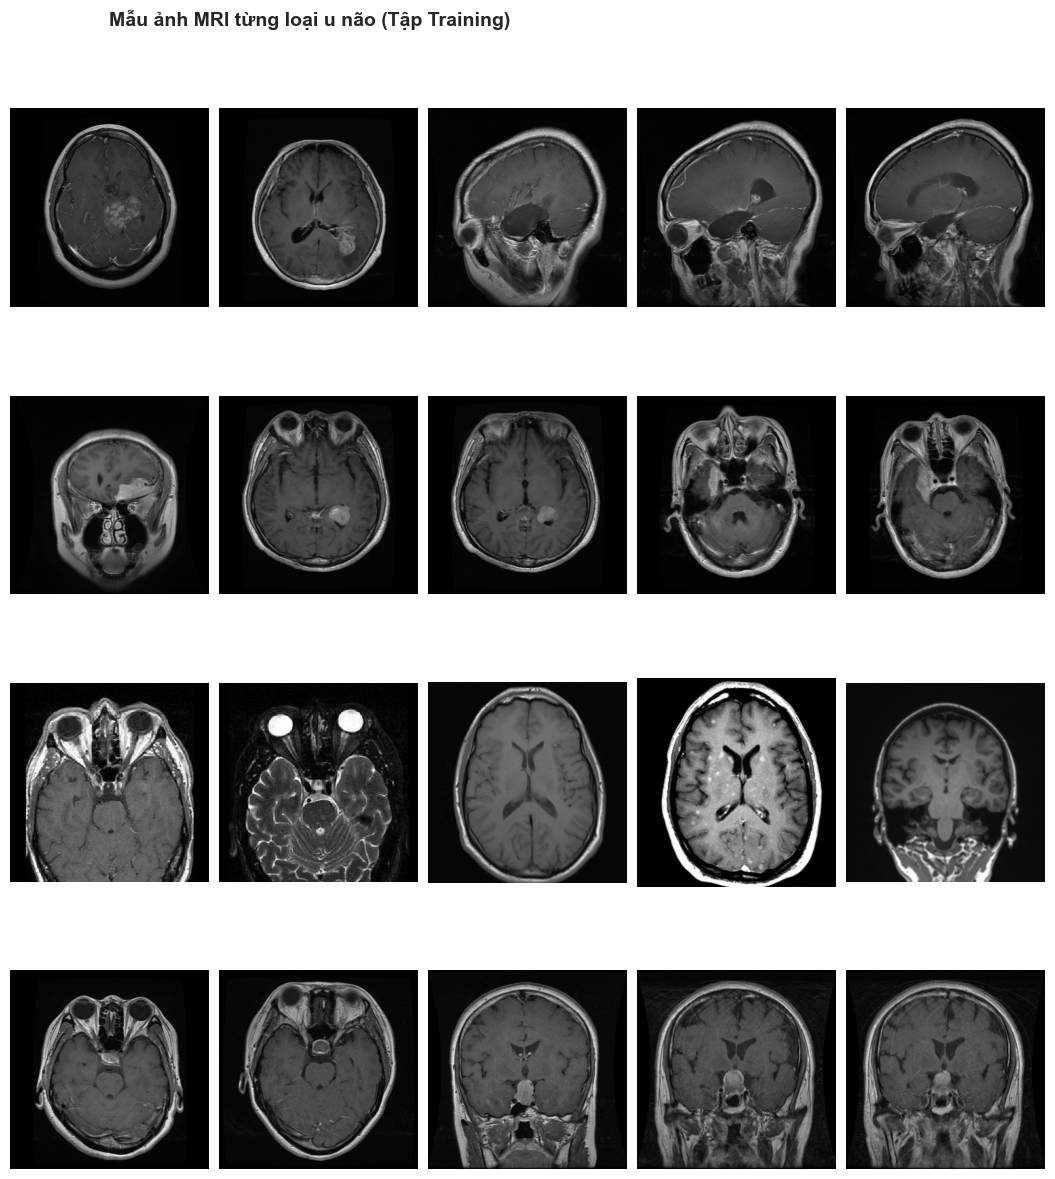

💾 Đã lưu: eda_sample_images.png


In [ ]:
# ============================================================
# Hiển thị lưới ảnh mẫu — 5 ảnh cho mỗi class
# ============================================================
N_SAMPLES = 5   # Số ảnh mẫu mỗi class

fig, axes = plt.subplots(len(CLASSES), N_SAMPLES,
                          figsize=(N_SAMPLES * 3, len(CLASSES) * 3))
fig.suptitle('Mẫu ảnh MRI từng loại u não (Tập Training)',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    cls_path = TRAIN_DIR / cls
    img_files = sorted(cls_path.glob('*.jpg'))[:N_SAMPLES]

    for col, img_path in enumerate(img_files):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB cho matplotlib
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            # Nhãn bên trái mỗi hàng
            axes[row, col].set_ylabel(CLASS_LABELS[cls],
                                       fontsize=12, fontweight='bold',
                                       rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.subplots_adjust(left=0.25)
plt.show()
print('💾 Đã lưu: eda_sample_images.png')

## 📐 Phần E — Kiểm tra kích thước ảnh

CNN yêu cầu tất cả ảnh phải cùng kích thước.
Cần biết kích thước gốc để quyết định resize về bao nhiêu.

In [ ]:
# ============================================================
# Kiểm tra kích thước (width, height) của tất cả ảnh trong Training
# ============================================================
sizes = []

for cls in CLASSES:
    cls_path = TRAIN_DIR / cls
    for img_path in cls_path.glob('*.jpg'):
        with Image.open(img_path) as img:
            w, h = img.size
            sizes.append({'class': CLASS_LABELS[cls], 'width': w, 'height': h,
                          'channels': len(img.getbands())})

df_sizes = pd.DataFrame(sizes)

print('📐 Thống kê kích thước ảnh:')
print(df_sizes[['width', 'height']].describe().round(1))
print(f'\nSố kích thước khác nhau (WxH): {df_sizes.groupby(["width","height"]).ngroups}')
print(f'Kích thước phổ biến nhất:')
print(df_sizes.groupby(['width','height']).size().sort_values(ascending=False).head(5))

In [ ]:
# ============================================================
# Vẽ scatter plot kích thước ảnh
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân phối kích thước ảnh', fontsize=13, fontweight='bold')

# Scatter: width vs height
for cls_label in df_sizes['class'].unique():
    subset = df_sizes[df_sizes['class'] == cls_label]
    axes[0].scatter(subset['width'], subset['height'], label=cls_label, alpha=0.5, s=20)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Width vs Height')
axes[0].legend()

# Histogram width
axes[1].hist(df_sizes['width'], bins=30, color='#2196F3', alpha=0.7, label='Width')
axes[1].hist(df_sizes['height'], bins=30, color='#FF9800', alpha=0.7, label='Height')
axes[1].set_xlabel('Kích thước (px)')
axes[1].set_ylabel('Số lượng ảnh')
axes[1].set_title('Phân phối Width & Height')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎨 Phần F — Phân tích pixel intensity

Histogram pixel cho thấy sự khác biệt về **độ sáng/tối** giữa các loại u.
Đây là manh mối quan trọng giúp model phân biệt các class.

In [ ]:
# ============================================================
# Vẽ histogram pixel intensity cho từng class
# Chỉ lấy 50 ảnh mỗi class để nhanh
# ============================================================
N_PIXEL_SAMPLES = 50
IMG_SIZE = (128, 128)   # Resize tạm để tính nhanh

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Histogram Pixel Intensity theo từng loại u não',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

colors_hist = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']

for i, cls in enumerate(CLASSES):
    cls_path = TRAIN_DIR / cls
    img_files = list(cls_path.glob('*.jpg'))[:N_PIXEL_SAMPLES]

    all_pixels = []
    for img_path in img_files:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)  # Đọc grayscale
        img = cv2.resize(img, IMG_SIZE)
        all_pixels.extend(img.flatten().tolist())

    axes[i].hist(all_pixels, bins=50, color=colors_hist[i],
                 alpha=0.8, edgecolor='none')
    axes[i].set_title(CLASS_LABELS[cls], fontweight='bold')
    axes[i].set_xlabel('Giá trị pixel (0-255)')
    axes[i].set_ylabel('Tần suất')
    axes[i].axvline(np.mean(all_pixels), color='black',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean={np.mean(all_pixels):.0f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('eda_pixel_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Mean Image — Ảnh trung bình của mỗi class
# Cho thấy pattern "điển hình" của từng loại u
# ============================================================
IMG_SIZE_MEAN = (128, 128)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Ảnh trung bình (Mean Image) — Pattern điển hình mỗi class',
             fontsize=13, fontweight='bold')

for i, cls in enumerate(CLASSES):
    cls_path = TRAIN_DIR / cls
    img_files = list(cls_path.glob('*.jpg'))[:100]  # Lấy 100 ảnh

    mean_img = np.zeros(IMG_SIZE_MEAN, dtype=np.float64)
    count = 0
    for img_path in img_files:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE_MEAN).astype(np.float64)
        mean_img += img
        count += 1

    mean_img = (mean_img / count).astype(np.uint8)

    axes[i].imshow(mean_img, cmap='gray')
    axes[i].set_title(CLASS_LABELS[cls], fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('eda_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu: eda_mean_images.png')

## ✅ Phần G — Tổng kết EDA

Sau khi chạy xong các phần trên, ghi lại những điểm quan trọng.

In [ ]:
# ============================================================
# In tổng kết để đưa vào báo cáo
# ============================================================
total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print('=' * 55)
print('📋 TỔNG KẾT EDA')
print('=' * 55)
print(f'Tổng số ảnh Training : {total_train}')
print(f'Tổng số ảnh Testing  : {total_test}')
print(f'Tổng cộng            : {total_train + total_test}')
print(f'Số class             : {len(CLASSES)}')
print()
print('Phân phối Training:')
for cls in CLASSES:
    pct = train_counts[cls] / total_train * 100
    bar = '█' * int(pct / 2)
    print(f'  {CLASS_LABELS[cls]:<15} {train_counts[cls]:>4} ảnh  {pct:5.1f}%  {bar}')
print()

# Kiểm tra class imbalance
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
ratio   = train_counts[max_cls] / train_counts[min_cls]
print(f'Tỷ lệ chênh lệch max/min: {ratio:.2f}x')
if ratio > 1.5:
    print('⚠️  Dữ liệu có thể mất cân bằng — cân nhắc dùng class_weight hoặc oversampling')
else:
    print('✅ Dữ liệu tương đối cân bằng')
print('=' * 55)